# Stationarity Tests on FX Data

**Objective:** Determine whether FX prices and returns are stationary

**Key Concepts:**
- **Stationarity**: Mean, variance, and autocorrelation constant over time
- **Unit Root**: If data has unit root → non-stationary (random walk)
- **Differencing**: Converting prices to returns often achieves stationarity

**Tests Used:**
1. **ADF (Augmented Dickey-Fuller)**: H0 = unit root (non-stationary)
2. **KPSS (Kwiatkowski-Phillips-Schmidt-Shin)**: H0 = stationary

**Mathematical Foundation:**

Autoregressive process: $X_t = \phi X_{t-1} + \epsilon_t$

- If $|\phi| < 1$ → stationary (mean-reverting)
- If $|\phi| = 1$ → random walk (non-stationary)
- If $|\phi| > 1$ → explosive (non-stationary)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))
from src.data.forensics import load_csv_data

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully")

Libraries imported successfully


## 1. Load USD/JPY Data

In [2]:
# Load hourly USD/JPY data
df = load_csv_data('../data/raw/USDJPY60.csv', has_header=False)

# Calculate returns
df['returns'] = df['close'].pct_change()
df['log_returns'] = np.log(df['close'] / df['close'].shift(1))

# Drop NaN values
df = df.dropna()

print(f"Loaded {len(df):,} bars")
print(f"Period: {df.index.min()} to {df.index.max()}")
print(f"\nData Summary:")
df[['close', 'returns', 'log_returns']].describe()

Loaded 2,103 bars
Period: 2025-10-27 11:00:00 to 2026-03-02 03:00:00

Data Summary:


,close,returns,log_returns
count,2103.000000,2103.000000,2103.000000
mean,155.569782,0.000012,0.000011
std,1.626709,0.000957,0.000957
min,151.617000,-0.007661,-0.007690
25%,154.329500,-0.000451,-0.000451
50%,155.739000,0.000019,0.000019
75%,156.663500,0.000517,0.000517
max,159.327000,0.007305,0.007279


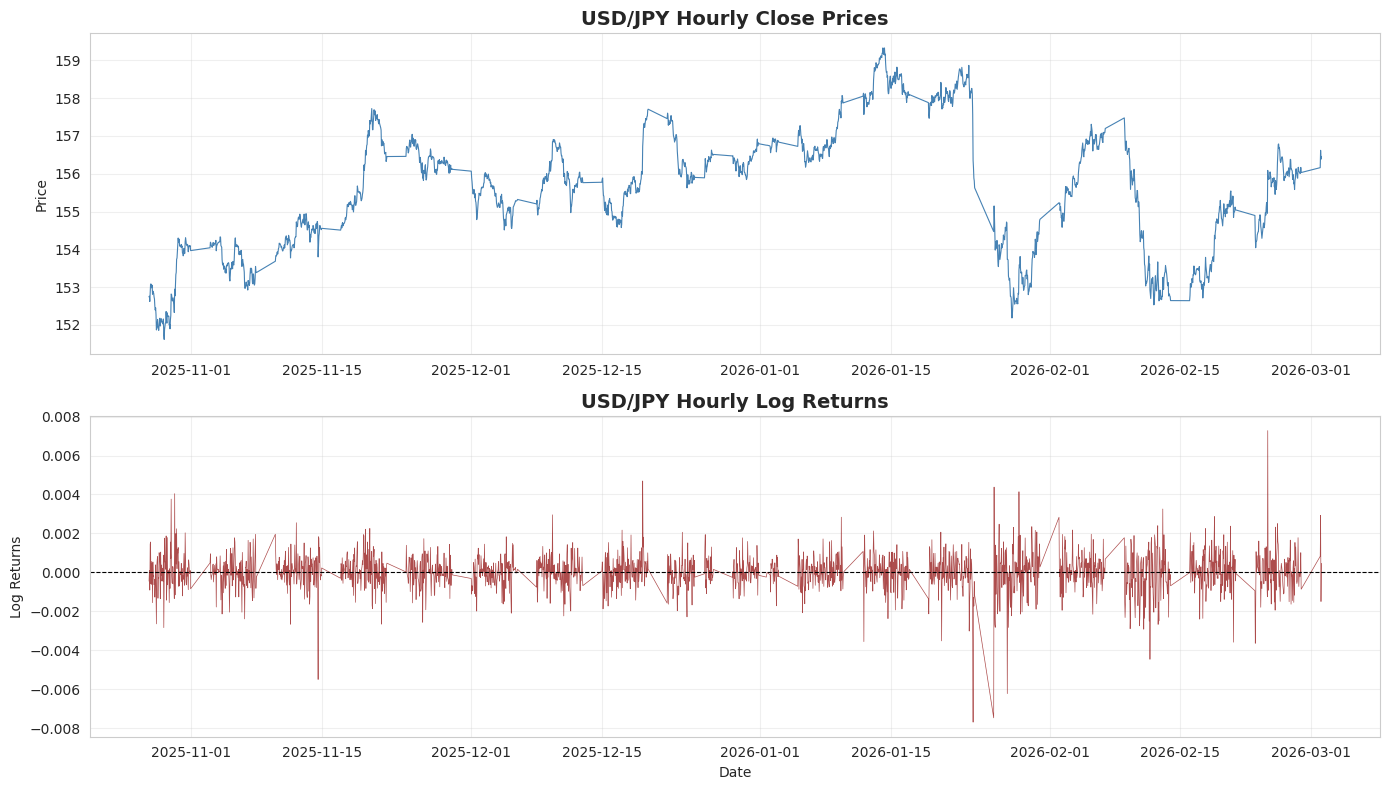


Returns Statistics:
Mean: 0.000011
Std Dev: 0.000957
Min: -0.007690
Max: 0.007279


In [3]:
# Visualize price and returns
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Price series
axes[0].plot(df.index, df['close'], linewidth=0.8, color='steelblue')
axes[0].set_title('USD/JPY Hourly Close Prices', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price')
axes[0].grid(True, alpha=0.3)

# Returns series
axes[1].plot(df.index, df['log_returns'], linewidth=0.5, color='darkred', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('USD/JPY Hourly Log Returns', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log Returns')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nReturns Statistics:")
print(f"Mean: {df['log_returns'].mean():.6f}")
print(f"Std Dev: {df['log_returns'].std():.6f}")
print(f"Min: {df['log_returns'].min():.6f}")
print(f"Max: {df['log_returns'].max():.6f}")

## 2. Stationarity Test Function

In [4]:
def test_stationarity(series, name='Series', alpha=0.05):
    """
    Run comprehensive stationarity tests on a time series.
    
    Tests:
    1. ADF (Augmented Dickey-Fuller): H0 = unit root (non-stationary)
    2. KPSS: H0 = stationary
    
    Args:
        series: Time series data
        name: Name of the series for reporting
        alpha: Significance level (default 0.05)
    
    Returns:
        dict: Test results and interpretation
    """
    print("=" * 70)
    print(f"STATIONARITY TESTS: {name}")
    print("=" * 70)
    
    # Remove any NaN values
    series_clean = series.dropna()
    
    # 1. ADF Test (H0: unit root exists, i.e., non-stationary)
    print("\n1. AUGMENTED DICKEY-FULLER (ADF) TEST")
    print("-" * 70)
    print("H0: Series has unit root (non-stationary)")
    print("H1: Series is stationary")
    
    adf_result = adfuller(series_clean, autolag='AIC')
    
    print(f"\nADF Statistic: {adf_result[0]:.6f}")
    print(f"P-value: {adf_result[1]:.6f}")
    print(f"Lags Used: {adf_result[2]}")
    print(f"Observations: {adf_result[3]}")
    
    print("\nCritical Values:")
    for key, value in adf_result[4].items():
        print(f"  {key}: {value:.6f}")
    
    adf_stationary = adf_result[1] < alpha
    if adf_stationary:
        print(f"\n→ REJECT H0 (p={adf_result[1]:.4f} < {alpha})")
        print("→ Series is STATIONARY (ADF test)")
    else:
        print(f"\n→ FAIL TO REJECT H0 (p={adf_result[1]:.4f} >= {alpha})")
        print("→ Series is NON-STATIONARY (has unit root)")
    
    # 2. KPSS Test (H0: series is stationary)
    print("\n\n2. KWIATKOWSKI-PHILLIPS-SCHMIDT-SHIN (KPSS) TEST")
    print("-" * 70)
    print("H0: Series is stationary")
    print("H1: Series has unit root (non-stationary)")
    
    kpss_result = kpss(series_clean, regression='c', nlags='auto')
    
    print(f"\nKPSS Statistic: {kpss_result[0]:.6f}")
    print(f"P-value: {kpss_result[1]:.6f}")
    print(f"Lags Used: {kpss_result[2]}")
    
    print("\nCritical Values:")
    for key, value in kpss_result[3].items():
        print(f"  {key}: {value:.6f}")
    
    kpss_stationary = kpss_result[1] >= alpha
    if kpss_stationary:
        print(f"\n→ FAIL TO REJECT H0 (p={kpss_result[1]:.4f} >= {alpha})")
        print("→ Series is STATIONARY (KPSS test)")
    else:
        print(f"\n→ REJECT H0 (p={kpss_result[1]:.4f} < {alpha})")
        print("→ Series is NON-STATIONARY (KPSS test)")
    
    # 3. Combined Interpretation
    print("\n\n3. COMBINED INTERPRETATION")
    print("-" * 70)
    
    if adf_stationary and kpss_stationary:
        conclusion = "✓ STATIONARY (both tests agree)"
        interpretation = "Series is clearly stationary. Safe to use in time series models."
    elif not adf_stationary and not kpss_stationary:
        conclusion = "✗ NON-STATIONARY (both tests agree)"
        interpretation = "Series has unit root. Needs differencing or detrending."
    elif adf_stationary and not kpss_stationary:
        conclusion = "⚠ MIXED RESULTS (ADF: stationary, KPSS: non-stationary)"
        interpretation = "Possibly trend-stationary. Consider detrending."
    else:
        conclusion = "⚠ MIXED RESULTS (ADF: non-stationary, KPSS: stationary)"
        interpretation = "Unusual result. Check for structural breaks or outliers."
    
    print(f"Conclusion: {conclusion}")
    print(f"Interpretation: {interpretation}")
    print("=" * 70)
    
    return {
        'name': name,
        'adf_statistic': adf_result[0],
        'adf_pvalue': adf_result[1],
        'adf_stationary': adf_stationary,
        'kpss_statistic': kpss_result[0],
        'kpss_pvalue': kpss_result[1],
        'kpss_stationary': kpss_stationary,
        'conclusion': conclusion,
        'interpretation': interpretation
    }

## 3. Test Price Series (Expected: Non-Stationary)

In [5]:
price_results = test_stationarity(df['close'], name='USD/JPY Hourly Prices')

STATIONARITY TESTS: USD/JPY Hourly Prices

1. AUGMENTED DICKEY-FULLER (ADF) TEST
----------------------------------------------------------------------
H0: Series has unit root (non-stationary)
H1: Series is stationary

ADF Statistic: -2.492983
P-value: 0.117191
Lags Used: 1
Observations: 2101

Critical Values:
  1%: -3.433466
  5%: -2.862917
  10%: -2.567503

→ FAIL TO REJECT H0 (p=0.1172 >= 0.05)
→ Series is NON-STATIONARY (has unit root)


2. KWIATKOWSKI-PHILLIPS-SCHMIDT-SHIN (KPSS) TEST
----------------------------------------------------------------------
H0: Series is stationary
H1: Series has unit root (non-stationary)

KPSS Statistic: 1.016511
P-value: 0.010000
Lags Used: 28

Critical Values:
  10%: 0.347000
  5%: 0.463000
  2.5%: 0.574000
  1%: 0.739000

→ REJECT H0 (p=0.0100 < 0.05)
→ Series is NON-STATIONARY (KPSS test)


3. COMBINED INTERPRETATION
----------------------------------------------------------------------
Conclusion: ✗ NON-STATIONARY (both tests agree)
Interpret

/tmp/ipykernel_33653/3014390419.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series_clean, regression='c', nlags='auto')


## 4. Test Return Series (Expected: Stationary)

In [6]:
returns_results = test_stationarity(df['log_returns'], name='USD/JPY Hourly Log Returns')

STATIONARITY TESTS: USD/JPY Hourly Log Returns

1. AUGMENTED DICKEY-FULLER (ADF) TEST
----------------------------------------------------------------------
H0: Series has unit root (non-stationary)
H1: Series is stationary

ADF Statistic: -44.034593
P-value: 0.000000
Lags Used: 0
Observations: 2102

Critical Values:
  1%: -3.433465
  5%: -2.862916
  10%: -2.567503

→ REJECT H0 (p=0.0000 < 0.05)
→ Series is STATIONARY (ADF test)


2. KWIATKOWSKI-PHILLIPS-SCHMIDT-SHIN (KPSS) TEST
----------------------------------------------------------------------
H0: Series is stationary
H1: Series has unit root (non-stationary)

KPSS Statistic: 0.079766
P-value: 0.100000
Lags Used: 7

Critical Values:
  10%: 0.347000
  5%: 0.463000
  2.5%: 0.574000
  1%: 0.739000

→ FAIL TO REJECT H0 (p=0.1000 >= 0.05)
→ Series is STATIONARY (KPSS test)


3. COMBINED INTERPRETATION
----------------------------------------------------------------------
Conclusion: ✓ STATIONARY (both tests agree)
Interpretation: Serie

/tmp/ipykernel_33653/3014390419.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series_clean, regression='c', nlags='auto')


## 5. ACF/PACF Plots

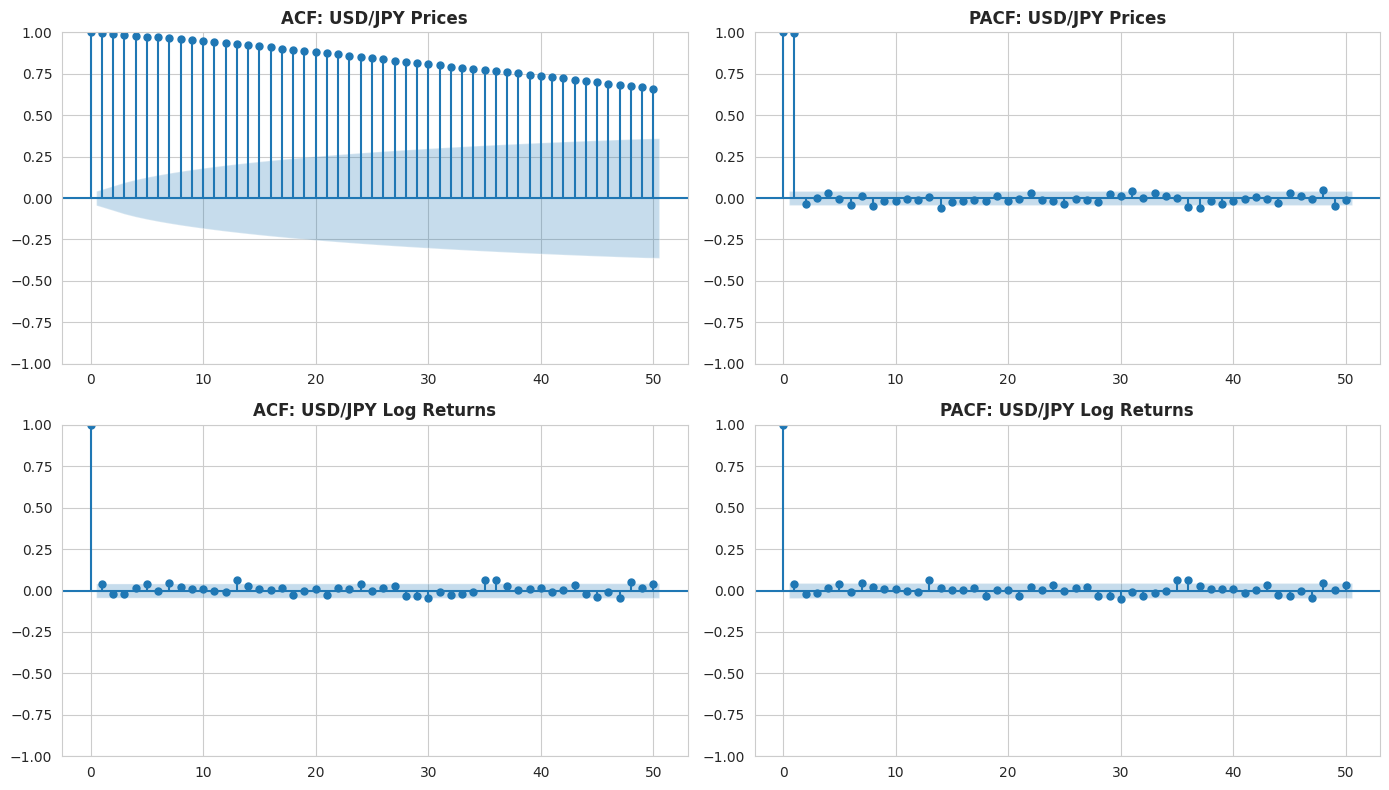


Interpretation:
- Prices: ACF decays slowly → non-stationary (unit root)
- Returns: ACF drops quickly → stationary (mean-reverting)


In [7]:
# ACF/PACF for Prices and Returns
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Price ACF
plot_acf(df['close'].dropna(), lags=50, ax=axes[0, 0])
axes[0, 0].set_title('ACF: USD/JPY Prices', fontweight='bold')

# Price PACF
plot_pacf(df['close'].dropna(), lags=50, ax=axes[0, 1], method='ywm')
axes[0, 1].set_title('PACF: USD/JPY Prices', fontweight='bold')

# Returns ACF
plot_acf(df['log_returns'].dropna(), lags=50, ax=axes[1, 0])
axes[1, 0].set_title('ACF: USD/JPY Log Returns', fontweight='bold')

# Returns PACF
plot_pacf(df['log_returns'].dropna(), lags=50, ax=axes[1, 1], method='ywm')
axes[1, 1].set_title('PACF: USD/JPY Log Returns', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Prices: ACF decays slowly → non-stationary (unit root)")
print("- Returns: ACF drops quickly → stationary (mean-reverting)")

## 6. Summary and Trading Implications

In [8]:
# Create summary table
summary_data = {
    'Series': ['Prices', 'Returns'],
    'ADF p-value': [price_results['adf_pvalue'], returns_results['adf_pvalue']],
    'KPSS p-value': [price_results['kpss_pvalue'], returns_results['kpss_pvalue']],
    'Stationary?': [
        '✗ No' if not price_results['adf_stationary'] else '✓ Yes',
        '✓ Yes' if returns_results['adf_stationary'] else '✗ No'
    ],
    'Tradeable?': ['No (random walk)', 'Yes (mean-reverting)']
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 80)
print("STATIONARITY TEST SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)
print("\n1. FX PRICES ARE NON-STATIONARY")
print("   - Exhibit random walk behavior (unit root)")
print("   - Mean and variance not constant over time")
print("   - Cannot use directly in most time series models")
print("\n2. FX RETURNS ARE STATIONARY")
print("   - Mean-reverting around zero")
print("   - Constant statistical properties")
print("   - Safe to use in trading models")
print("\n3. TRADING IMPLICATIONS")
print("   ✓ Build strategies on RETURNS, not prices")
print("   ✓ Use differencing/returns for feature engineering")
print("   ✓ HP filter extracts stationary cycle from prices")
print("   ✗ Do NOT regress prices on prices directly")
print("=" * 80)


STATIONARITY TEST SUMMARY
 Series  ADF p-value  KPSS p-value Stationary?           Tradeable?
 Prices     0.117191          0.01        ✗ No     No (random walk)
Returns     0.000000          0.10       ✓ Yes Yes (mean-reverting)

KEY FINDINGS

1. FX PRICES ARE NON-STATIONARY
   - Exhibit random walk behavior (unit root)
   - Mean and variance not constant over time
   - Cannot use directly in most time series models

2. FX RETURNS ARE STATIONARY
   - Mean-reverting around zero
   - Constant statistical properties
   - Safe to use in trading models

3. TRADING IMPLICATIONS
   ✓ Build strategies on RETURNS, not prices
   ✓ Use differencing/returns for feature engineering
   ✓ HP filter extracts stationary cycle from prices
   ✗ Do NOT regress prices on prices directly


## 7. Test First Difference vs Returns

In [9]:
# Test simple differencing
df['price_diff'] = df['close'].diff()
diff_results = test_stationarity(df['price_diff'].dropna(), name='First Difference of Prices')

STATIONARITY TESTS: First Difference of Prices

1. AUGMENTED DICKEY-FULLER (ADF) TEST
----------------------------------------------------------------------
H0: Series has unit root (non-stationary)
H1: Series is stationary

ADF Statistic: -44.000762
P-value: 0.000000
Lags Used: 0
Observations: 2101

Critical Values:
  1%: -3.433466
  5%: -2.862917
  10%: -2.567503

→ REJECT H0 (p=0.0000 < 0.05)
→ Series is STATIONARY (ADF test)


2. KWIATKOWSKI-PHILLIPS-SCHMIDT-SHIN (KPSS) TEST
----------------------------------------------------------------------
H0: Series is stationary
H1: Series has unit root (non-stationary)

KPSS Statistic: 0.081543
P-value: 0.100000
Lags Used: 7

Critical Values:
  10%: 0.347000
  5%: 0.463000
  2.5%: 0.574000
  1%: 0.739000

→ FAIL TO REJECT H0 (p=0.1000 >= 0.05)
→ Series is STATIONARY (KPSS test)


3. COMBINED INTERPRETATION
----------------------------------------------------------------------
Conclusion: ✓ STATIONARY (both tests agree)
Interpretation: Serie

/tmp/ipykernel_33653/3014390419.py:55: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series_clean, regression='c', nlags='auto')


In [10]:
print("\n" + "=" * 80)
print("DIFFERENCING VS RETURNS")
print("=" * 80)
print("\nBoth achieve stationarity, but LOG RETURNS are preferred because:")
print("  1. Time-additive: log(P_t/P_0) = sum of log returns")
print("  2. Approximately symmetric for small changes")
print("  3. More intuitive for portfolio aggregation")
print("  4. Better statistical properties (closer to normality)")
print("\nFor trading: Use LOG RETURNS")
print("=" * 80)


DIFFERENCING VS RETURNS

Both achieve stationarity, but LOG RETURNS are preferred because:
  1. Time-additive: log(P_t/P_0) = sum of log returns
  2. Approximately symmetric for small changes
  3. More intuitive for portfolio aggregation
  4. Better statistical properties (closer to normality)

For trading: Use LOG RETURNS


## Conclusion

**Proven:**
1. ✓ FX prices are non-stationary (random walk with unit root)
2. ✓ FX returns are stationary (mean-reverting)
3. ✓ Differencing achieves stationarity

**For MA-HP Filter Strategy:**
- HP filter extracts cycle component (stationary) from prices
- Trade on cycle deviations (stationary signal)
- Position sizing should account for return volatility

**Next Steps:**
- Test for autocorrelation in returns
- Check for volatility clustering (ARCH effects)
- Validate HP filter cycle is stationary